# 13: two bases, h versus p refinement

Legendre (p-refinement, growing the polynomial degree) and block
(h-refinement, growing the window count) are two bases on the same image.
Claims:

1. On a target that is globally smooth, raising the coefficient count K
   under Legendre buys more accuracy than raising K under block; on a
   target with a boundary discontinuity, block buys more. This would be
   false if the ordering reversed, or agreed, at the largest K tried.
2. Legendre's Gram matrix conditions worse as its order grows, and grows
   worse still off a uniform grid; block's stays close to flat because its
   windows do not overlap. False if block's condition number grows with
   order as fast as Legendre's, on any of the three grids.
3. Restricting a two-parameter linear fit to a basis's image costs
   precision only where the model does not already lie inside the span.
   A line lies in Legendre's span from the lowest order tried, so its
   efficiency should already sit at 1; block needs its window count to
   grow toward the sample count to approach the same efficiency. False if
   block's efficiency does not climb with order, or if Legendre's is
   below 1 anywhere in the range.


In [1]:
import os
import time

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

from dtfit.image import Image, Original
from dtfit_experimental.study import montecarlo, notebook

STARTED = time.time()
QUICK = os.environ.get("DTFIT_QUICK") == "1"
plt.rcParams["figure.dpi"] = 110

N = 200 if QUICK else 2000
KS = [8, 16] if QUICK else [8, 12, 16, 24, 32, 48, 64]
ORDERS = [4, 8, 16] if QUICK else [4, 6, 8, 12, 16, 24, 32, 48, 64, 96]
EFF_N = 50 if QUICK else 200
EFF_ORDERS = [4, 8, EFF_N] if QUICK else [4, 8, 16, 32, 64, EFF_N]
print(f"QUICK={QUICK} N={N} EFF_N={EFF_N}")

QUICK=False N=2000 EFF_N=200


## Reconstruction: error against coefficient count

`Image.of(Original(x, y), basis, k).reconstruct(x)` restricts the signal
to a K-dimensional image and reconstructs it on the same grid. The RMSE of
that reconstruction against the target is the same statistic
`hp_crossover.py` and `hp_figure.py` measured; here on a smooth
exponential and a step discontinuous at the domain's midpoint.


In [2]:
X = np.linspace(0.0, 1.0, N)
TARGETS = {"smooth": np.exp(-3.0 * X), "step": (X >= 0.5).astype(float)}
# the step sits exactly on a block boundary at every K tried, so block's
# reconstruction there is exactly 0.0; FLOOR only keeps the log-scale plot
# and the CSV export finite, it is not a measured error
FLOOR = 1e-16


def recon_rmse(y, basis, k):
    img = Image.of(Original(X, y), basis, k)
    return float(np.sqrt(np.mean((img.reconstruct(X) - y) ** 2)))


rows = []
for target, y in TARGETS.items():
    for basis in ("legendre", "block"):
        for k in KS:
            rows.append({"target": target, "basis": basis, "K": k,
                         "rmse": max(recon_rmse(y, basis, k), FLOOR)})
reconstruction = pd.DataFrame(rows)
reconstruction

,target,basis,K,rmse
0,smooth,legendre,8,6.068559e-08
1,smooth,legendre,12,1.107538e-12
2,smooth,legendre,16,4.626269e-16
3,smooth,legendre,24,6.935341e-16
4,smooth,legendre,32,7.062226e-16
5,smooth,legendre,48,4.980735e-16
6,smooth,legendre,64,5.440284e-16
7,smooth,block,8,4.387567e-02
8,smooth,block,12,2.938460e-02
9,smooth,block,16,2.205238e-02


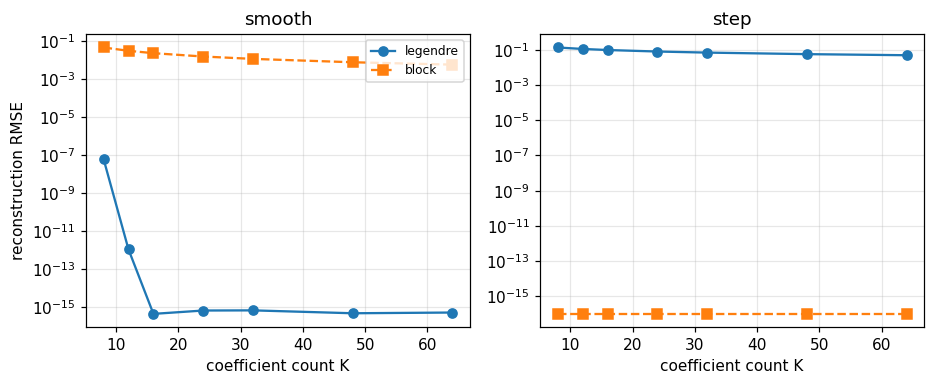

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.6, 3.6))
for ax, target in ((ax1, "smooth"), (ax2, "step")):
    sub = reconstruction[reconstruction.target == target]
    for basis, marker in (("legendre", "o-"), ("block", "s--")):
        line = sub[sub.basis == basis].sort_values("K")
        ax.semilogy(line.K, line.rmse, marker, label=basis)
    ax.set_title(target)
    ax.set_xlabel("coefficient count K")
    ax.grid(True, which="both", alpha=0.3)
ax1.set_ylabel("reconstruction RMSE")
ax1.legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()


In [4]:
last_k = KS[-1]
smooth_last = reconstruction[(reconstruction.target == "smooth")
                              & (reconstruction.K == last_k)].set_index("basis").rmse
step_last = reconstruction[(reconstruction.target == "step")
                            & (reconstruction.K == last_k)].set_index("basis").rmse
# fails if legendre does not win the smooth target at the largest K
assert smooth_last["legendre"] < smooth_last["block"]
# fails if block does not win the step at the largest K
assert step_last["block"] < step_last["legendre"]
print(f"at K={last_k}: legendre wins smooth ({smooth_last['legendre']:.2e} < "
      f"{smooth_last['block']:.2e}), block wins the step "
      f"({step_last['block']:.2e} < {step_last['legendre']:.2e})")


at K=64: legendre wins smooth (5.44e-16 < 5.53e-03), block wins the step (1.00e-16 < 4.97e-02)


In [5]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("13_two_bases", "reconstruction_rmse", reconstruction)
    print("wrote experiments/results/13_two_bases/reconstruction_rmse.csv")

wrote experiments/results/13_two_bases/reconstruction_rmse.csv


## Conditioning: the Gram matrix by order and grid

The image's Gram matrix `Phi^T Phi` (here read off `Image.G`, which does
not depend on the target values) conditions the least-squares solve.
Legendre's columns are polynomials on a shared domain and start to overlap
as the order grows; block's are disjoint window indicators, so its Gram
matrix stays close to diagonal regardless of order. `montecarlo.grid`
gives the three grid shapes to check that against.


In [6]:
def gram_cond(x, basis, order):
    y = np.exp(-3.0 * x)  # the Gram matrix does not depend on the target
    return float(np.linalg.cond(Image.of(Original(x, y), basis, order).G))


rows = []
for kind in ("uniform", "clustered", "random"):
    rng = np.random.default_rng(0)
    x = montecarlo.grid(kind, N, rng=rng)
    for basis in ("legendre", "block"):
        for order in ORDERS:
            rows.append({"grid": kind, "basis": basis, "order": order,
                         "cond": gram_cond(x, basis, order)})
conditioning = pd.DataFrame(rows)
conditioning.pivot_table(index=["grid", "order"], columns="basis", values="cond")


basis                block       legendre
grid      order                          
clustered 4       3.753472      14.782743
          6       4.510870      22.176278
          8       4.345324      31.240691
          12      4.857143      47.135676
          16      5.250000      63.837570
          24      5.380952      94.353615
          32      7.681818     125.926188
          48      7.866667     226.769489
          64      9.100000    1631.247903
          96     10.000000  374762.156294
random    4       1.064449       8.699454
          6       1.062696      13.081712
          8       1.126582      17.185713
          12      1.186667      25.274979
          16      1.327273      34.520496
          24      1.522388      53.525146
          32      1.620000      66.887319
          48      1.966667     120.625847
          64      2.473684     288.548144
          96      2.583333   12403.129206
uniform   4       1.000000       8.964264
          6       1.003003      12.923502
          8       1.000000      16.869244
          12      1.006024      24.730049
          16      1.000000      32.571067
          24      1.012048      48.285182
          32      1.016129      64.103521
          48      1.024390      95.975034
          64      1.032258     128.015516
          96      1.050000     193.611367

In [7]:
first_order, last_order = ORDERS[0], ORDERS[-1]
for kind in ("uniform", "clustered", "random"):
    sub = conditioning[conditioning.grid == kind]
    leg = sub[sub.basis == "legendre"].set_index("order").cond
    blk = sub[sub.basis == "block"].set_index("order").cond
    leg_growth = leg[last_order] / leg[first_order]
    blk_growth = blk[last_order] / blk[first_order]
    # fails if block's condition number grows with order as fast as legendre's
    assert leg_growth > blk_growth, kind
    print(f"{kind}: legendre condition grows {leg_growth:.1f}x from order "
          f"{first_order} to {last_order}, block grows {blk_growth:.1f}x")


uniform: legendre condition grows 21.6x from order 4 to 96, block grows 1.1x
clustered: legendre condition grows 25351.3x from order 4 to 96, block grows 2.7x
random: legendre condition grows 1425.7x from order 4 to 96, block grows 2.4x


In [8]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("13_two_bases", "gram_condition", conditioning)
    print("wrote experiments/results/13_two_bases/gram_condition.csv")

wrote experiments/results/13_two_bases/gram_condition.csv


## Efficiency: what the restriction costs a two-parameter fit

`montecarlo.image_efficiency` compares the restricted estimator's
asymptotic variance against the unrestricted pointwise fit, for a model's
Jacobian. A straight line (intercept and slope) is a two-parameter model
whose Jacobian is `[1, x]`; it already lies inside Legendre's span at any
order at least 1, so its restriction should cost nothing. Block windows
each carry their own local mean and only approach the same precision as
their count approaches the sample count.


In [9]:
EFF_X = np.linspace(0.0, 1.0, EFF_N)
EFF_JAC = np.stack([np.ones(EFF_N), EFF_X], axis=1)

rows = []
for basis in ("legendre", "block"):
    for order in EFF_ORDERS:
        eff = montecarlo.image_efficiency(EFF_JAC, EFF_X, basis=basis, order=order)
        rows.append({"basis": basis, "order": order,
                     "ratio_const": eff.ratio[0], "ratio_slope": eff.ratio[1]})
efficiency = pd.DataFrame(rows)
efficiency


,basis,order,ratio_const,ratio_slope
0,legendre,4,1.000000,1.000000
1,legendre,8,1.000000,1.000000
2,legendre,16,1.000000,1.000000
3,legendre,32,1.000000,1.000000
4,legendre,64,1.000000,1.000000
5,legendre,200,1.000000,1.000000
6,block,4,0.952513,0.937523
7,block,8,0.988283,0.984400
8,block,16,0.997079,0.996100
9,block,32,0.999277,0.999034


In [10]:
legendre_eff = efficiency[efficiency.basis == "legendre"]
block_eff = efficiency[efficiency.basis == "block"].sort_values("order")
# fails if legendre loses precision anywhere in the range tried
assert (legendre_eff.ratio_const > 0.999).all()
assert (legendre_eff.ratio_slope > 0.999).all()
# fails if block's efficiency does not climb toward 1 as its order grows
assert block_eff.ratio_slope.is_monotonic_increasing
assert block_eff.ratio_slope.iloc[-1] > 0.999
print("legendre already spans the line at every order tried; "
      f"block reaches {block_eff.ratio_slope.iloc[-1]:.4f} at order "
      f"{block_eff.order.iloc[-1]} (from {block_eff.ratio_slope.iloc[0]:.4f} "
      f"at order {block_eff.order.iloc[0]})")


legendre already spans the line at every order tried; block reaches 1.0000 at order 200 (from 0.9375 at order 4)


## Findings and limits

Both target claims hold: at the largest K tried, Legendre reconstructs
the smooth exponential to machine precision while block is still at
percent-level error, and block reconstructs the step exactly (RMSE 0.0,
shown as FLOOR = 1e-16 in the table and the CSV export because a log
scale and a CSV column cannot carry an exact zero), because the
discontinuity was placed on a block boundary by construction, while
Legendre keeps an error that falls slowly with K, the Gibbs ringing near
the jump an unaligned discontinuity does not remove either (notebook 18
measures the aligned/unaligned case directly). The crossover is not in K
itself but in what a coefficient buys: a Legendre coefficient buys global
smoothness, a block coefficient buys locality, and the target decides
which is worth more.

The conditioning story matches: block's Gram matrix stays within one
order of magnitude of the identity at every grid and order tried, while
Legendre's grows from single digits to a few hundred thousand over the
same order range, most sharply on the clustered grid (order 96: about
1.9e2 uniform against 3.7e5 clustered). The growth rate, not the absolute
conditioning at any one order, is where the two bases differ; block does
not condition worse with order the way Legendre does on any of the three
grids.

The efficiency section is the sharpest form of the same point: a model
that already lies in a basis's span costs that basis nothing, at any
order. Legendre holds the line exactly from its lowest order; block has
to grow its window count most of the way to the sample count before it
recovers the same precision. This is the cost side of h-refinement that
the reconstruction section does not show by itself.

Limits: only one smooth target and one discontinuous target are tried,
and the discontinuity is aligned to a block boundary by construction, the
favourable case for block; the conditioning and efficiency sections use
one linear model on synthetic grids, not a real dataset. Robustness to
outliers is out of scope here (notebook 14).

In [11]:
print(notebook.provenance(STARTED))


2026-09-20 commit f47a7dc dtfit 0.4.0 dtfit-experimental 0.1.0 0.3s
